In [2]:
"""
Evaluates a trained FMEncoderChain checkpoint against a dataset.
Organises results by spectral loss and parameter error.
"""

import torch
import numpy as np
import json
import os
import argparse
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from nnAudio.features import CQT2010v2

import sys
sys.path.append('..')
from FMEncoderChain import FMEncoderChain
from fm_chain import fm_renderer
from loss_batch import compute_spectrogram_cqt_batched, cqt_spectrogram_loss_batched
from dataset_chain import FMDataset

# ─────────────────────────────────────────────────────────────────────────────

def evaluate(data_dir, checkpoint_path, n_samples=200, Fs=16000, duration=1.0,
             f0=110.0, device_str='cpu'):

    device = torch.device(device_str)
    
    # load dataset
    dataset = FMDataset(save_dir=data_dir)
    n_samples = min(n_samples, len(dataset))
    print(f"Evaluating {n_samples} examples from {data_dir}")

    # load encoder
    encoder = FMEncoderChain(n_bins=224).to(device)
    encoder.load_state_dict(torch.load(checkpoint_path, map_location=device))
    encoder.eval()
    print(f"Loaded checkpoint: {checkpoint_path}")

    # CQT transform
    cqt_transform = CQT2010v2(
        sr=Fs, hop_length=512, n_bins=224, bins_per_octave=32
    ).to(device)

    results = []

    with torch.no_grad():
        for idx in range(n_samples):
            params, spec = dataset[idx]
            spec = spec.float().unsqueeze(0).to(device)

            # encoder forward pass
            predicted = encoder(spec)

            # render predicted audio
            f0_t = torch.tensor([f0], dtype=torch.float32).to(device)
            audio_pred = fm_renderer(
                f0_t,
                predicted['ratios'],
                predicted['levels'],
                Fs, duration
            )

            # compute predicted spectrogram
            pred_spec = compute_spectrogram_cqt_batched(audio_pred, cqt_transform)

            # spectral loss
            spectral_loss = cqt_spectrogram_loss_batched(pred_spec, spec).item()

            # ground truth params
            gt_ratios = params['ratios'].float()
            gt_levels = params['levels'].float()
            pred_ratios = predicted['ratios'][0].cpu()
            pred_levels = predicted['levels'][0].cpu()

            # parameter errors
            ratio_error = (pred_ratios - gt_ratios).abs().mean().item()
            level_error = (pred_levels - gt_levels).abs().mean().item()
            param_error = ratio_error + level_error

            results.append({
                'idx': idx,
                'spectral_loss': spectral_loss,
                'param_error': param_error,
                'ratio_error': ratio_error,
                'level_error': level_error,
                'gt_r0': gt_ratios[0].item(),
                'gt_r1': gt_ratios[1].item(),
                'gt_l0': gt_levels[0].item(),
                'gt_l1': gt_levels[1].item(),
                'pred_r0': pred_ratios[0].item(),
                'pred_r1': pred_ratios[1].item(),
                'pred_l0': pred_levels[0].item(),
                'pred_l1': pred_levels[1].item(),
                'spec': spec[0].cpu().numpy(),
                'pred_spec': pred_spec[0].cpu().numpy(),
            })

    # sort by spectral loss
    results_by_spectral = sorted(results, key=lambda x: x['spectral_loss'])
    # sort by parameter error
    results_by_param = sorted(results, key=lambda x: x['param_error'])

    return results, results_by_spectral, results_by_param


def plot_summary(results, results_by_spectral, results_by_param, n_show=5):
    """Plot overview of results and best/worst examples."""

    spectral_losses = [r['spectral_loss'] for r in results]
    param_errors = [r['param_error'] for r in results]
    ratio_errors = [r['ratio_error'] for r in results]
    level_errors = [r['level_error'] for r in results]

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('FMEncoderChain Evaluation', fontsize=14, fontweight='bold')

    # ── row 1: distributions ──────────────────────────────────────────────────
    ax1 = fig.add_subplot(3, 4, 1)
    ax1.hist(spectral_losses, bins=40, color='#378ADD', alpha=0.8)
    ax1.set_title('spectral loss distribution')
    ax1.set_xlabel('spectral loss')
    ax1.axvline(np.median(spectral_losses), color='red', linestyle='--',
                label=f'median={np.median(spectral_losses):.4f}')
    ax1.legend(fontsize=8)

    ax2 = fig.add_subplot(3, 4, 2)
    ax2.hist(param_errors, bins=40, color='#D85A30', alpha=0.8)
    ax2.set_title('parameter error distribution')
    ax2.set_xlabel('mean abs error')
    ax2.axvline(np.median(param_errors), color='red', linestyle='--',
                label=f'median={np.median(param_errors):.4f}')
    ax2.legend(fontsize=8)

    ax3 = fig.add_subplot(3, 4, 3)
    ax3.scatter(
        [r['gt_r0'] for r in results],
        [r['pred_r0'] for r in results],
        alpha=0.3, s=10, color='#534AB7', label='op0'
    )
    ax3.scatter(
        [r['gt_r1'] for r in results],
        [r['pred_r1'] for r in results],
        alpha=0.3, s=10, color='#1D9E75', label='op1'
    )
    lims = [1, 8]
    ax3.plot(lims, lims, 'k--', alpha=0.5, linewidth=0.8)
    ax3.set_xlabel('GT ratio'); ax3.set_ylabel('pred ratio')
    ax3.set_title('ratio prediction (GT vs pred)')
    ax3.legend(fontsize=8)

    ax4 = fig.add_subplot(3, 4, 4)
    ax4.scatter(
        [r['gt_l0'] for r in results],
        [r['pred_l0'] for r in results],
        alpha=0.3, s=10, color='#534AB7', label='op0'
    )
    ax4.scatter(
        [r['gt_l1'] for r in results],
        [r['pred_l1'] for r in results],
        alpha=0.3, s=10, color='#1D9E75', label='op1'
    )
    lims = [0, 1]
    ax4.plot(lims, lims, 'k--', alpha=0.5, linewidth=0.8)
    ax4.set_xlabel('GT level'); ax4.set_ylabel('pred level')
    ax4.set_title('level prediction (GT vs pred)')
    ax4.legend(fontsize=8)

    # ── row 2: best spectral examples ────────────────────────────────────────
    for i, r in enumerate(results_by_spectral[:n_show]):
        ax = fig.add_subplot(3, n_show, n_show + i + 1)
        ax.plot(r['spec'], color='#378ADD', linewidth=0.8, label='GT')
        ax.plot(r['pred_spec'], color='#D85A30', linewidth=0.8,
                linestyle='--', label='pred')
        ax.set_title(
            f'best #{i+1} spec\n'
            f'sl={r["spectral_loss"]:.4f}\n'
            f'r=[{r["gt_r0"]:.0f},{r["gt_r1"]:.0f}]→[{r["pred_r0"]:.1f},{r["pred_r1"]:.1f}]\n'
            f'l=[{r["gt_l0"]:.2f},{r["gt_l1"]:.2f}]→[{r["pred_l0"]:.2f},{r["pred_l1"]:.2f}]',
            fontsize=7
        )
        if i == 0:
            ax.legend(fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])

    # ── row 3: worst spectral examples ───────────────────────────────────────
    for i, r in enumerate(results_by_spectral[-n_show:]):
        ax = fig.add_subplot(3, n_show, 2*n_show + i + 1)
        ax.plot(r['spec'], color='#378ADD', linewidth=0.8, label='GT')
        ax.plot(r['pred_spec'], color='#D85A30', linewidth=0.8,
                linestyle='--', label='pred')
        ax.set_title(
            f'worst #{i+1} spec\n'
            f'sl={r["spectral_loss"]:.4f}\n'
            f'r=[{r["gt_r0"]:.0f},{r["gt_r1"]:.0f}]→[{r["pred_r0"]:.1f},{r["pred_r1"]:.1f}]\n'
            f'l=[{r["gt_l0"]:.2f},{r["gt_l1"]:.2f}]→[{r["pred_l0"]:.2f},{r["pred_l1"]:.2f}]',
            fontsize=7
        )
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()


def print_summary_table(results_by_spectral, results_by_param, n_show=10):
    """Print sorted tables of best and worst examples."""

    print("\n" + "="*80)
    print(f"{'BEST by spectral loss':^80}")
    print("="*80)
    print(f"{'idx':>5} {'spec_loss':>10} {'param_err':>10} "
          f"{'GT r0':>6} {'PR r0':>6} {'GT r1':>6} {'PR r1':>6} "
          f"{'GT l0':>6} {'PR l0':>6} {'GT l1':>6} {'PR l1':>6}")
    print("-"*80)
    for r in results_by_spectral[:n_show]:
        print(f"{r['idx']:>5} {r['spectral_loss']:>10.4f} {r['param_error']:>10.4f} "
              f"{r['gt_r0']:>6.1f} {r['pred_r0']:>6.2f} "
              f"{r['gt_r1']:>6.1f} {r['pred_r1']:>6.2f} "
              f"{r['gt_l0']:>6.2f} {r['pred_l0']:>6.2f} "
              f"{r['gt_l1']:>6.2f} {r['pred_l1']:>6.2f}")

    print("\n" + "="*80)
    print(f"{'WORST by spectral loss':^80}")
    print("="*80)
    print(f"{'idx':>5} {'spec_loss':>10} {'param_err':>10} "
          f"{'GT r0':>6} {'PR r0':>6} {'GT r1':>6} {'PR r1':>6} "
          f"{'GT l0':>6} {'PR l0':>6} {'GT l1':>6} {'PR l1':>6}")
    print("-"*80)
    for r in results_by_spectral[-n_show:]:
        print(f"{r['idx']:>5} {r['spectral_loss']:>10.4f} {r['param_error']:>10.4f} "
              f"{r['gt_r0']:>6.1f} {r['pred_r0']:>6.2f} "
              f"{r['gt_r1']:>6.1f} {r['pred_r1']:>6.2f} "
              f"{r['gt_l0']:>6.2f} {r['pred_l0']:>6.2f} "
              f"{r['gt_l1']:>6.2f} {r['pred_l1']:>6.2f}")

    print("\n" + "="*80)
    print(f"{'WORST by parameter error':^80}")
    print("="*80)
    print(f"{'idx':>5} {'spec_loss':>10} {'param_err':>10} "
          f"{'GT r0':>6} {'PR r0':>6} {'GT r1':>6} {'PR r1':>6} "
          f"{'GT l0':>6} {'PR l0':>6} {'GT l1':>6} {'PR l1':>6}")
    print("-"*80)
    for r in results_by_param[-n_show:]:
        print(f"{r['idx']:>5} {r['spectral_loss']:>10.4f} {r['param_error']:>10.4f} "
              f"{r['gt_r0']:>6.1f} {r['pred_r0']:>6.2f} "
              f"{r['gt_r1']:>6.1f} {r['pred_r1']:>6.2f} "
              f"{r['gt_l0']:>6.2f} {r['pred_l0']:>6.2f} "
              f"{r['gt_l1']:>6.2f} {r['pred_l1']:>6.2f}")

    # aggregate stats
    print("\n" + "="*80)
    print(f"{'AGGREGATE STATISTICS':^80}")
    print("="*80)
    print(f"{'metric':<30} {'mean':>10} {'median':>10} {'std':>10}")
    print("-"*80)
    for key, label in [
        ('spectral_loss', 'spectral loss'),
        ('param_error',   'parameter error'),
        ('ratio_error',   'ratio error'),
        ('level_error',   'level error'),
    ]:
        vals = [r[key] for r in results_by_spectral]
        print(f"{label:<30} {np.mean(vals):>10.4f} {np.median(vals):>10.4f} {np.std(vals):>10.4f}")

    # per-parameter ratio accuracy
    print("\nratio prediction accuracy (within 0.5 of GT):")
    r0_acc = np.mean([abs(r['pred_r0'] - r['gt_r0']) < 0.5 for r in results_by_spectral])
    r1_acc = np.mean([abs(r['pred_r1'] - r['gt_r1']) < 0.5 for r in results_by_spectral])
    print(f"  op0 ratio: {r0_acc*100:.1f}%")
    print(f"  op1 ratio: {r1_acc*100:.1f}%")


Evaluating 200 examples from B:\TrainingData\Chain_stage1
Loaded checkpoint: B:\TrainingData\Chain_stage1\output\encoder_epoch_199.pt
Low pass filter created, time used = 0.0010 seconds
num_octave =  7
No early downsampling is required, downsample_factor =  1
Early downsampling filter created,                         time used = 0.0000 seconds
CQT kernels created, time used = 0.0010 seconds


C:\Users\Marcus\AppData\Local\Programs\Python\Python312\Lib\site-packages\nnAudio\utils.py:510: UserWarning: 
input size = torch.Size([1, 1, 250])	kernel size = 512
padding with reflection mode might not be the best choice, try using constant padding
  warnings.warn(



                             BEST by spectral loss                              
  idx  spec_loss  param_err  GT r0  PR r0  GT r1  PR r1  GT l0  PR l0  GT l1  PR l1
--------------------------------------------------------------------------------
  140     0.0183     0.9306    6.0   4.84    4.0   4.00   0.16   0.04   1.08   0.50
   99     0.0185     1.4249    6.0   4.85    4.0   4.00   0.16   0.04   2.07   0.50
   39     0.0231     4.2040    3.0   4.70    1.0   4.12   0.21   0.02   3.91   0.50
   80     0.0329     2.4414    5.0   3.12    8.0   7.19   0.29   0.04   2.45   0.50
   64     0.0347     2.5548    4.0   3.09    8.0   6.81   0.31   0.04   3.23   0.50
   42     0.0399     1.4184    1.0   1.99    8.0   7.74   0.37   0.07   1.78   0.50
   30     0.0429     1.8827    5.0   4.77    1.0   4.12   0.32   0.03   0.62   0.50
  118     0.0448     2.7790    8.0   4.68    5.0   4.97   0.34   0.06   2.42   0.50
   75     0.0492     4.7160    8.0   4.48    7.0   4.78   0.41   0.03   3.81   0.

C:\Users\Marcus\AppData\Local\Temp\ipykernel_22596\1399472279.py:201: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


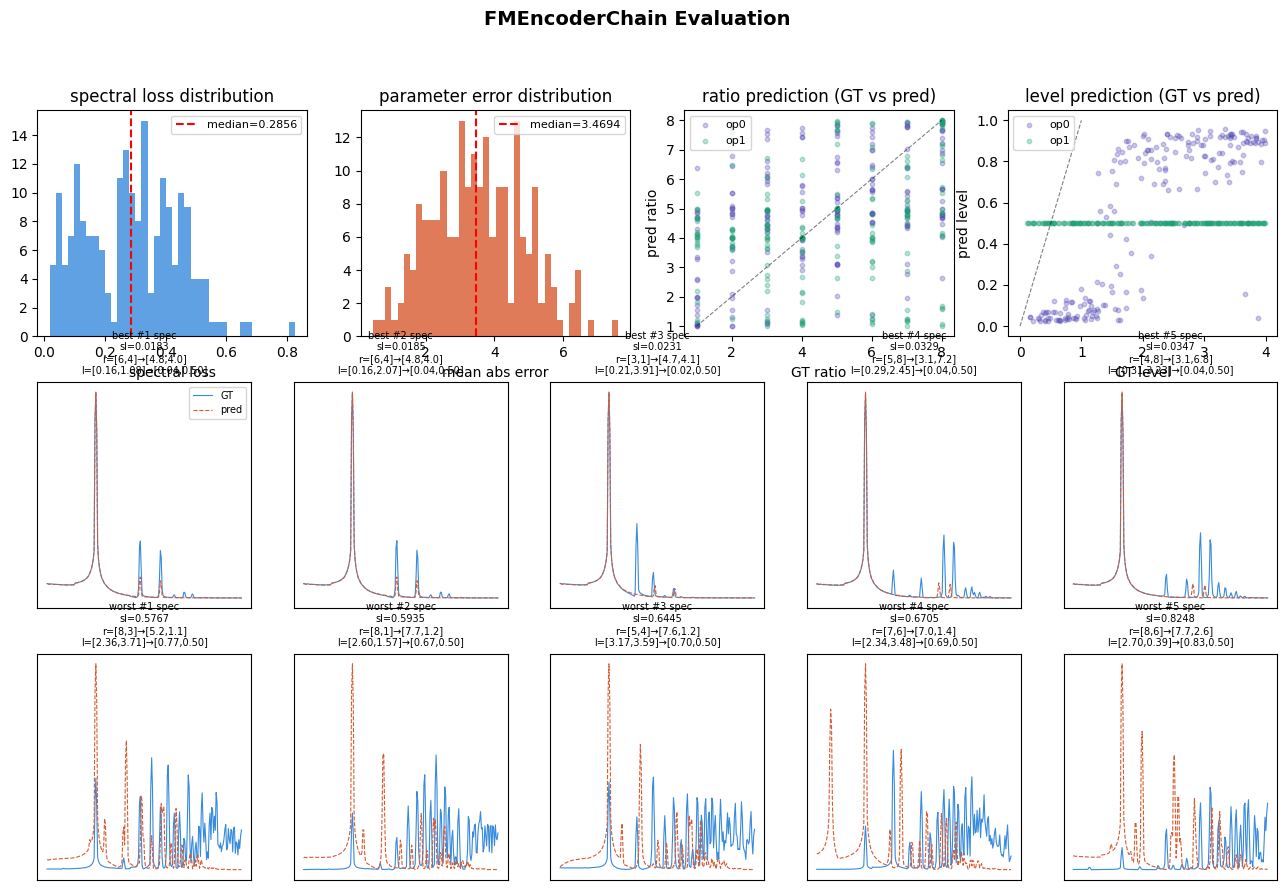

In [8]:
results, by_spectral, by_param = evaluate(
    data_dir='B:\\TrainingData\\Chain_stage1',
    checkpoint_path='B:\\TrainingData\\Chain_stage1\\output\\encoder_epoch_199.pt',
    n_samples=200,
    f0=110.0
)
print_summary_table(by_spectral, by_param)
plot_summary(results, by_spectral, by_param)

Evaluating 200 examples from B:\TrainingData\Chain_stage2
Loaded checkpoint: B:\TrainingData\Chain_stage2\attempt2\encoder_epoch_199.pt
Low pass filter created, time used = 0.0011 seconds
num_octave =  7
No early downsampling is required, downsample_factor =  1
Early downsampling filter created,                         time used = 0.0000 seconds
CQT kernels created, time used = 0.0010 seconds


C:\Users\Marcus\AppData\Local\Programs\Python\Python312\Lib\site-packages\nnAudio\utils.py:510: UserWarning: 
input size = torch.Size([1, 1, 250])	kernel size = 512
padding with reflection mode might not be the best choice, try using constant padding
  warnings.warn(



                             BEST by spectral loss                              
  idx  spec_loss  param_err  GT r0  PR r0  GT r1  PR r1  GT l0  PR l0  GT l1  PR l1
--------------------------------------------------------------------------------
  160     0.0017     2.6983    7.0   1.74    5.0   5.00   0.01   0.13   0.13   0.13
  130     0.0018     2.7635    2.0   7.47    1.0   1.00   0.05   0.11   0.30   0.30
    7     0.0019     1.4412    4.0   6.87    1.0   1.00   0.14   0.14   0.23   0.25
   11     0.0020     0.3347    3.0   3.57    8.0   8.00   0.01   0.09   0.50   0.49
  102     0.0025     0.4070    3.0   2.40    6.0   6.01   0.36   0.18   0.12   0.10
  164     0.0026     2.7327    8.0   2.59    8.0   8.00   0.13   0.09   0.52   0.50
   72     0.0029     1.9786    7.0   3.19    7.0   6.98   0.25   0.13   0.26   0.25
   38     0.0029     0.0322    6.0   6.01    1.0   1.00   0.27   0.22   0.41   0.41
  151     0.0030     0.0155    3.0   2.99    7.0   6.99   0.57   0.57   0.34   0.

C:\Users\Marcus\AppData\Local\Temp\ipykernel_25896\1399472279.py:201: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


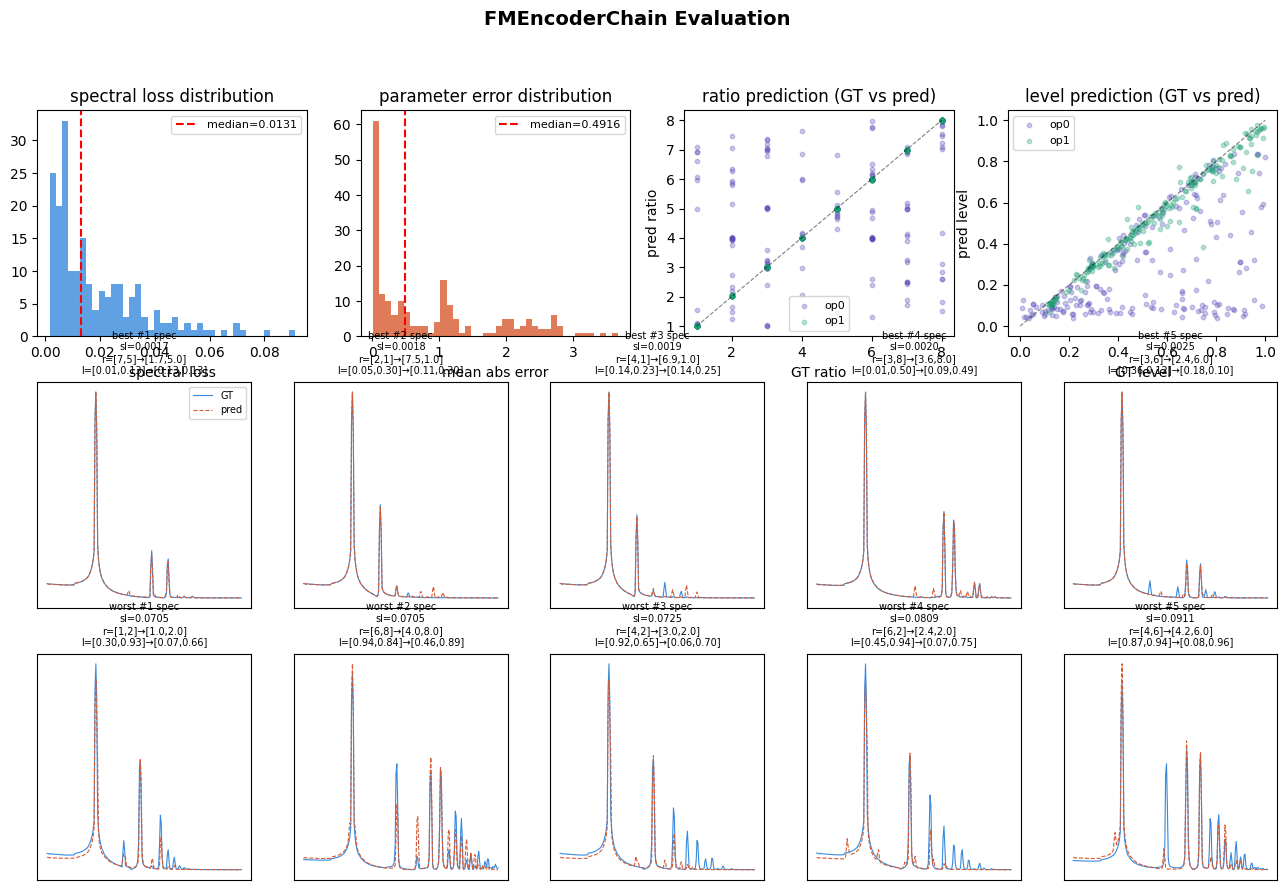

In [3]:
results, by_spectral, by_param = evaluate(
    data_dir='B:\\TrainingData\\Chain_stage2',
    checkpoint_path='B:\\TrainingData\\Chain_stage2\\attempt2\\encoder_epoch_199.pt',
    n_samples=200,
    f0=110.0
)
print_summary_table(by_spectral, by_param)
plot_summary(results, by_spectral, by_param)

Evaluating 200 examples from B:\TrainingData\Chain_stage2
Loaded checkpoint: B:\TrainingData\Chain_stage2\attempt2\encoder_epoch_86.pt
Low pass filter created, time used = 0.0000 seconds
num_octave =  7
No early downsampling is required, downsample_factor =  1
Early downsampling filter created,                         time used = 0.0000 seconds
CQT kernels created, time used = 0.0020 seconds

                             BEST by spectral loss                              
  idx  spec_loss  param_err  GT r0  PR r0  GT r1  PR r1  GT l0  PR l0  GT l1  PR l1
--------------------------------------------------------------------------------
   11     0.0009     0.5082    3.0   3.97    8.0   8.00   0.01   0.05   0.50   0.50
   57     0.0026     0.0347    7.0   7.01    5.0   5.00   0.13   0.08   0.28   0.29
   94     0.0031     0.0671    1.0   1.04    6.0   6.00   0.39   0.30   0.28   0.27
   70     0.0031     0.7230    6.0   4.76    6.0   6.01   0.24   0.05   0.30   0.31
  164     0.0032     1

C:\Users\Marcus\AppData\Local\Temp\ipykernel_25896\1399472279.py:201: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


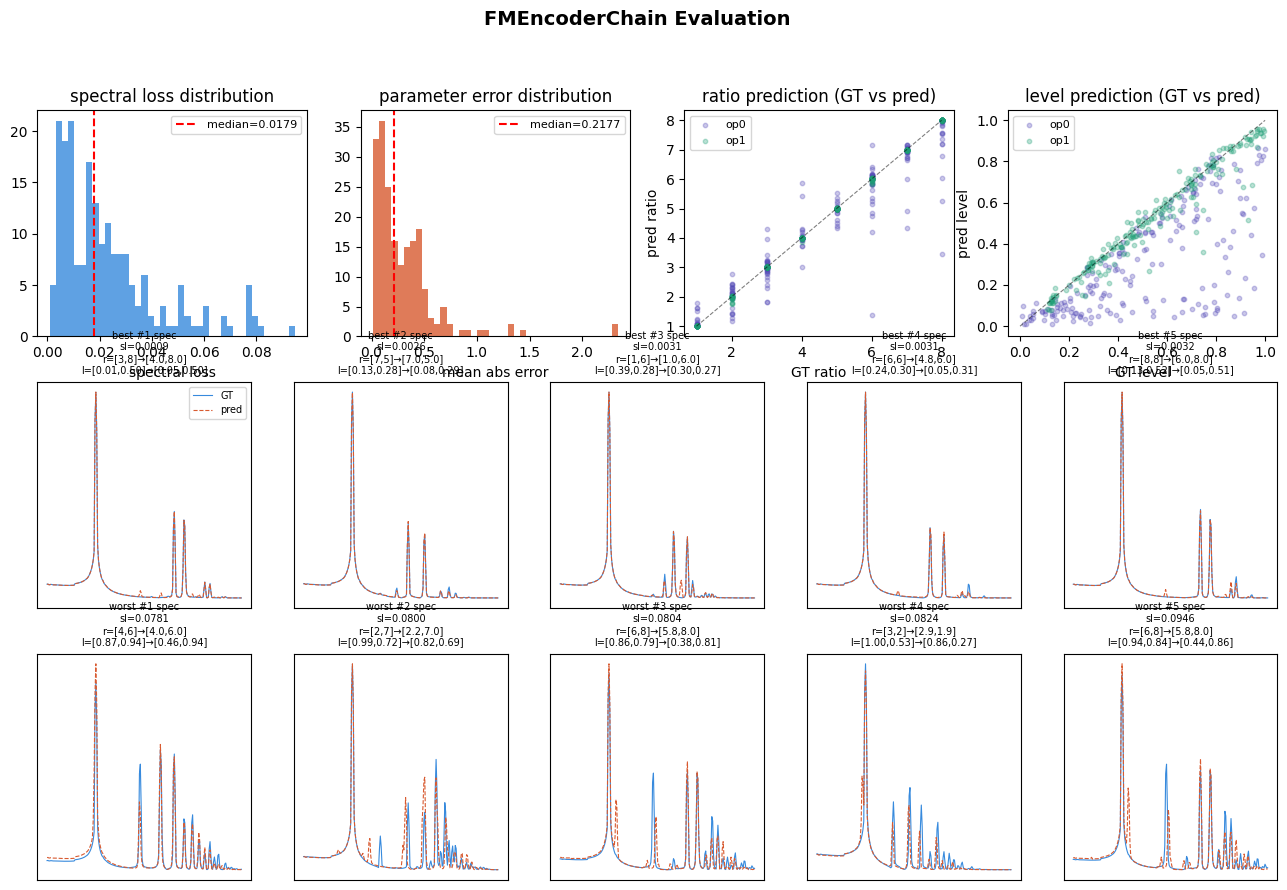

In [4]:
results, by_spectral, by_param = evaluate(
    data_dir='B:\\TrainingData\\Chain_stage2',
    checkpoint_path='B:\\TrainingData\\Chain_stage2\\attempt2\\encoder_epoch_86.pt',
    n_samples=200,
    f0=110.0
)
print_summary_table(by_spectral, by_param)
plot_summary(results, by_spectral, by_param)

Evaluating 200 examples from B:\TrainingData\Chain_stage2
Loaded checkpoint: B:\TrainingData\Chain_stage2\attempt3\encoder_epoch_199.pt
Low pass filter created, time used = 0.0010 seconds
num_octave =  7
No early downsampling is required, downsample_factor =  1
Early downsampling filter created,                         time used = 0.0000 seconds
CQT kernels created, time used = 0.0011 seconds

                             BEST by spectral loss                              
  idx  spec_loss  param_err  GT r0  PR r0  GT r1  PR r1  GT l0  PR l0  GT l1  PR l1
--------------------------------------------------------------------------------
  130     0.0008     1.7336    2.0   5.42    1.0   1.00   0.05   0.08   0.30   0.31
  121     0.0011     2.4144    8.0   3.20    8.0   7.99   0.15   0.13   0.30   0.29
   11     0.0020     0.0812    3.0   3.07    8.0   8.00   0.01   0.08   0.50   0.50
    7     0.0021     0.6575    4.0   5.27    1.0   1.00   0.14   0.12   0.23   0.26
   82     0.0021     

C:\Users\Marcus\AppData\Local\Temp\ipykernel_25896\1399472279.py:201: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


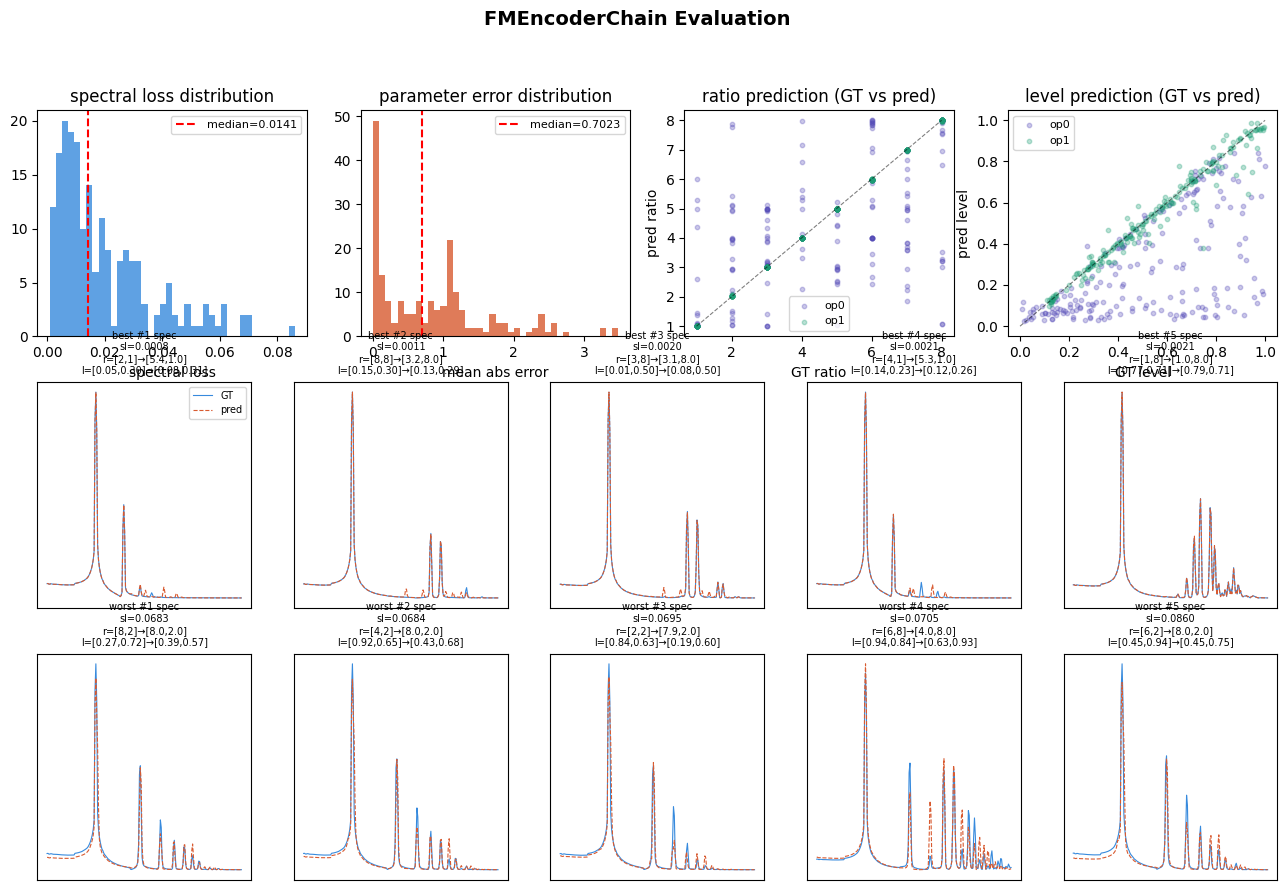

In [5]:
results, by_spectral, by_param = evaluate(
    data_dir='B:\\TrainingData\\Chain_stage2',
    checkpoint_path='B:\\TrainingData\\Chain_stage2\\attempt3\\encoder_epoch_199.pt',
    n_samples=200,
    f0=110.0
)
print_summary_table(by_spectral, by_param)
plot_summary(results, by_spectral, by_param)